# Company Clustering & Anomaly Detection
**Unsupervised Financial Profile Analysis** — SEC 10-Q/10-K Data

**Pipeline:**
1. Feature Engineering — 11 financial ratios từ raw SEC facts
2. Preprocessing — Median Imputation, RobustScaler
3. Dimensionality Reduction — PCA
4. Clustering — K-Means (Elbow + Silhouette + Davies-Bouldin)
5. Anomaly Detection — Isolation Forest
6. Full Visualization Dashboard


## 0. Install & Import


In [69]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'scikit-learn', 'matplotlib', 'seaborn', 'pandas', 'numpy', '-q'],
               capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.impute import SimpleImputer

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print('✓ All imports successful')


✓ All imports successful


## 1. Load & Explore Data


In [70]:
df = pd.read_csv('Raw/data_raw.csv')
df = df[~df['is_amended'].fillna(False).astype(bool)].copy()
df["year_q"] = df["year_q"].astype(str)

print(f'Period     : {df["year_q"].min()} → {df["year_q"].max()}')

print(f'Shape      : {df.shape}')
print(f'Companies  : {df["ticker"].nunique()}')
print(f'Period     : {df["year_q"].min()} → {df["year_q"].max()}')
df.head(3)


Period     : 2009-Q1 → nan
Shape      : (26288, 32)
Companies  : 1369
Period     : 2009-Q1 → nan


,adsh,CostOfGoodsSold,LiabilitiesNoncurrent,Assets,AssetsCurrent,CashAndCashEquivalentsAtCarryingValue,GeneralAndAdministrativeExpense,Goodwill,GrossProfit,IncomeLossFromContinuingOperationsBeforeIncomeTaxesExtraordinaryItemsNoncontrollingInterest,...,StockholdersEquity,WeightedAverageNumberOfDilutedSharesOutstanding,WeightedAverageNumberOfSharesOutstandingBasic,cik,sic,amendment_adsh,is_amended,ticker,year_q,AssetsNoncurrent
0,248815000067,2.788000e+09,NaN,3.767000e+09,2.736000e+09,869000000.0,NaN,320000000.0,1.479000e+09,NaN,...,187000000.0,765000000.0,765000000.0,2488.0,3674.0,0.0,False,amd,2015-Q3,NaN
1,248816000111,3.321000e+09,NaN,3.767000e+09,2.736000e+09,549000000.0,NaN,553000000.0,1.978000e+09,-74000000.0,...,538000000.0,754000000.0,754000000.0,2488.0,3674.0,0.0,False,amd,2015-Q4,NaN
2,248816000124,7.040000e+08,NaN,3.084000e+09,2.320000e+09,805000000.0,NaN,278000000.0,3.260000e+08,NaN,...,-412000000.0,777000000.0,777000000.0,2488.0,3674.0,0.0,False,amd,2016-Q1,NaN


In [71]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
miss_df = pd.DataFrame({'Missing': missing, 'Missing %': missing_pct})
miss_df[miss_df['Missing'] > 0].sort_values('Missing %', ascending=False)


,Missing,Missing %
AssetsNoncurrent,24235,92.2
LiabilitiesNoncurrent,22193,84.4
GeneralAndAdministrativeExpense,17690,67.3
NonoperatingIncomeExpense,16920,64.4
Revenues,16663,63.4
IncomeLossFromContinuingOperationsBeforeIncomeTaxesExtraordinaryItemsNoncontrollingInterest,16514,62.8
OperatingExpenses,14658,55.8
OtherNonoperatingIncomeExpense,13168,50.1
SellingGeneralAndAdministrativeExpense,10006,38.1
InterestExpense,9587,36.5


## 2. Feature Engineering

Tính **11 financial ratios** từ raw facts. Dùng `safe_ratio()` để:
- Tránh division-by-zero (threshold = 0.1% of median)
- Clip extreme outliers theo từng ratio

| Ratio | Formula | Clip Range |
|---|---|---|
| GrossMargin | GrossProfit / Revenue | [-2, 1] |
| OperatingMargin | OperatingIncome / Revenue | [-2, 1] |
| NetProfitMargin | NetIncome / Revenue | [-2, 1] |
| ROA | NetIncome / Assets | [-1, 1] |
| ROE | NetIncome / Equity | [-3, 3] |
| CurrentRatio | CurrentAssets / CurrentLiab | [0, 10] |
| DebtRatio | TotalLiab / Assets | [0, 5] |
| CashRatio | Cash / CurrentAssets | [0, 3] |
| AssetTurnover | Revenue / Assets | [0, 5] |
| SBCIntensity | SBC / Revenue | [0, 1] |
| RevenueGrowth | YoY Growth | [-2, 10] |


In [72]:
# Chuẩn hóa dữ liệu tài chính theo công ty bằng cách lấy trung bình 4 quý gần nhất
df['year_q_dt'] = pd.PeriodIndex(df['year_q'], freq='Q')
df_sorted = df.sort_values(['ticker', 'year_q_dt'])

recent = (df_sorted.groupby('ticker')
          .apply(lambda g: g.tail(4), include_groups=False)
          .reset_index(level=0).reset_index(drop=True))

agg_cols = ['Assets', 'AssetsCurrent', 'CashAndCashEquivalentsAtCarryingValue',
            'GrossProfit', 'NetIncomeLoss', 'OperatingIncomeLoss', 'Revenues',
            'StockholdersEquity', 'Liabilities', 'LiabilitiesCurrent',
            'InterestExpense', 'ShareBasedCompensation']

agg = recent.groupby('ticker')[agg_cols].mean()
agg['sic'] = recent.groupby('ticker')['sic'].first()
print(f'Aggregated: {len(agg)} companies × {len(agg_cols)} raw features')


Aggregated: 1369 companies × 12 raw features


In [73]:
def safe_ratio(num, denom, lo=-10, hi=10):
    """Compute ratio only where denominator is meaningful; clip extremes."""
    med = denom.abs().median()
    threshold = max(med * 0.001, 1.0)
    mask = denom.abs() > threshold
    result = pd.Series(np.nan, index=num.index)
    result[mask] = (num[mask] / denom[mask]).clip(lo, hi)
    return result

fe = pd.DataFrame(index=agg.index)
fe['GrossMargin']     = safe_ratio(agg['GrossProfit'],        agg['Revenues'],               -2,  1)
fe['OperatingMargin'] = safe_ratio(agg['OperatingIncomeLoss'], agg['Revenues'],              -2,  1)
fe['NetProfitMargin'] = safe_ratio(agg['NetIncomeLoss'],       agg['Revenues'],              -2,  1)
fe['ROA']             = safe_ratio(agg['NetIncomeLoss'],       agg['Assets'],                -1,  1)
fe['ROE']             = safe_ratio(agg['NetIncomeLoss'],       agg['StockholdersEquity'],    -3,  3)
fe['CurrentRatio']    = safe_ratio(agg['AssetsCurrent'],       agg['LiabilitiesCurrent'],     0, 10)
fe['DebtRatio']       = safe_ratio(agg['Liabilities'],         agg['Assets'],                 0,  5)
fe['CashRatio']       = safe_ratio(agg['CashAndCashEquivalentsAtCarryingValue'],
                                    agg['AssetsCurrent'],                                     0,  3)
fe['AssetTurnover']   = safe_ratio(agg['Revenues'],            agg['Assets'],                 0,  5)
fe['SBCIntensity']    = safe_ratio(agg['ShareBasedCompensation'], agg['Revenues'],            0,  1)

# YoY Revenue Growth
def yoy_growth(g):
    g2 = g.sort_values('year_q_dt')
    first, last = g2['Revenues'].iloc[0], g2['Revenues'].iloc[-1]
    if len(g2) >= 4 and abs(first) > 1e3 and not pd.isna(first):
        return np.clip((last - first) / abs(first), -2, 10)
    return np.nan

fe['RevenueGrowth'] = df_sorted.groupby('ticker').apply(yoy_growth, include_groups=False)

print(f'Feature matrix: {fe.shape}')
fe.describe().round(3)
# 1369 công ty × 11 features


Feature matrix: (1369, 11)


,GrossMargin,OperatingMargin,NetProfitMargin,ROA,ROE,CurrentRatio,DebtRatio,CashRatio,AssetTurnover,SBCIntensity,RevenueGrowth
count,416.000,518.000,528.000,1154.000,1147.000,1280.000,935.000,1143.000,535.000,452.000,345.000
mean,0.365,-0.469,-0.523,-0.119,0.074,2.418,0.765,0.314,0.549,0.184,1.955
std,0.382,0.863,0.874,0.307,0.820,2.207,0.904,0.332,0.660,0.323,3.481
min,-2.000,-2.000,-2.000,-1.000,-3.000,0.000,0.003,0.000,0.000,0.000,-1.000
25%,0.165,-0.919,-1.169,-0.120,-0.071,1.045,0.350,0.112,0.164,0.007,-0.345
50%,0.356,-0.021,-0.059,0.009,0.048,1.842,0.547,0.230,0.361,0.024,0.420
75%,0.567,0.093,0.058,0.038,0.141,3.041,0.764,0.418,0.680,0.145,2.699
max,1.000,1.000,1.000,1.000,3.000,10.000,5.000,3.000,5.000,1.000,10.000


## 3. Preprocessing


Before: 1369 | After dropping sparse: 980
Final matrix: (980, 11)


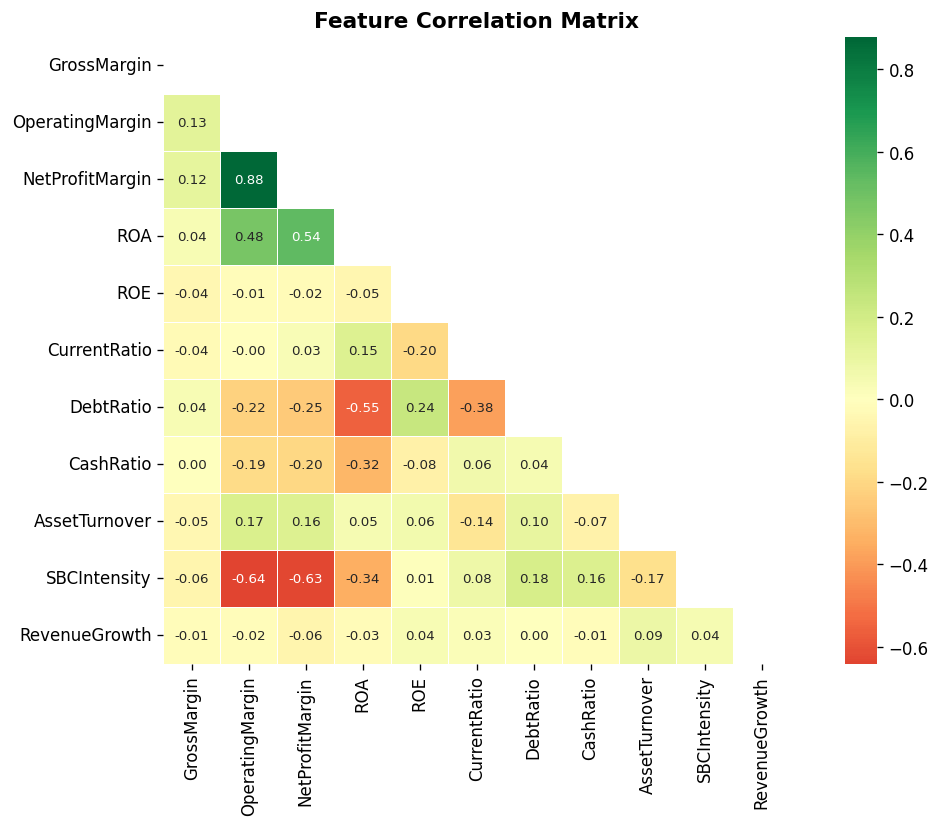

In [74]:
# Drop companies with >50% missing features
threshold = int(len(fe.columns) * 0.5)
fe_clean = fe.dropna(thresh=threshold)
print(f'Before: {len(fe)} | After dropping sparse: {len(fe_clean)}')

# Impute with median
imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(fe_clean),
                     index=fe_clean.index, columns=fe_clean.columns)

# RobustScaler — robust to outliers
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_imp)
print(f'Final matrix: {X_scaled.shape}')

# Feature correlation heatmap
fig, ax = plt.subplots(figsize=(10, 7))
corr = X_imp.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlGn', center=0, ax=ax,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.5, square=True)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Dimensionality Reduction — PCA


Components for 90% variance: 2


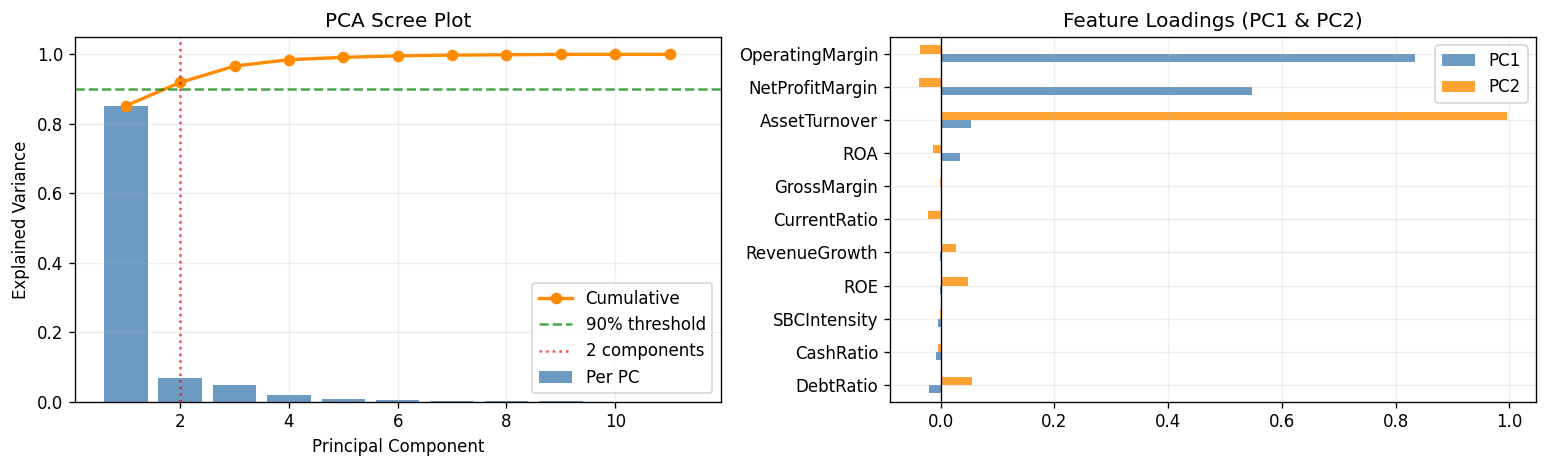

X_pca shape: (980, 2)


In [75]:
# Full PCA for variance analysis
pca_full = PCA(random_state=42).fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = int(np.searchsorted(cumvar, 0.90)) + 1
print(f'Components for 90% variance: {n_components_90}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Scree plot
evr = pca_full.explained_variance_ratio_[:12]
cv  = cumvar[:12]
ax1.bar(range(1, len(evr)+1), evr, color='steelblue', alpha=0.8, label='Per PC')
ax1.plot(range(1, len(cv)+1), cv, 'o-', color='darkorange', lw=2, label='Cumulative')
ax1.axhline(0.9, color='green', linestyle='--', alpha=0.7, label='90% threshold')
ax1.axvline(n_components_90, color='red', linestyle=':', alpha=0.7,
            label=f'{n_components_90} components')
ax1.set_xlabel('Principal Component'); ax1.set_ylabel('Explained Variance')
ax1.set_title('PCA Scree Plot'); ax1.legend(); ax1.grid(True, alpha=0.2)

# Feature loadings PC1 & PC2
pca2_obj = PCA(n_components=2, random_state=42).fit(X_scaled)
loadings = pd.DataFrame(pca2_obj.components_.T,
                        index=X_imp.columns, columns=['PC1','PC2'])
loadings.sort_values('PC1').plot(kind='barh', ax=ax2,
                                  color=['steelblue','darkorange'], alpha=0.8)
ax2.set_title('Feature Loadings (PC1 & PC2)')
ax2.axvline(0, color='black', lw=0.8); ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Reduce for clustering
pca_model = PCA(n_components=n_components_90, random_state=42)
X_pca = pca_model.fit_transform(X_scaled)
X_2d  = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
print(f'X_pca shape: {X_pca.shape}')


## 5. Clustering — K-Means


Best K = 2
Silhouette Score : 0.8356  (>0.5 = good separation)
Davies-Bouldin   : 0.2733  (lower = better)


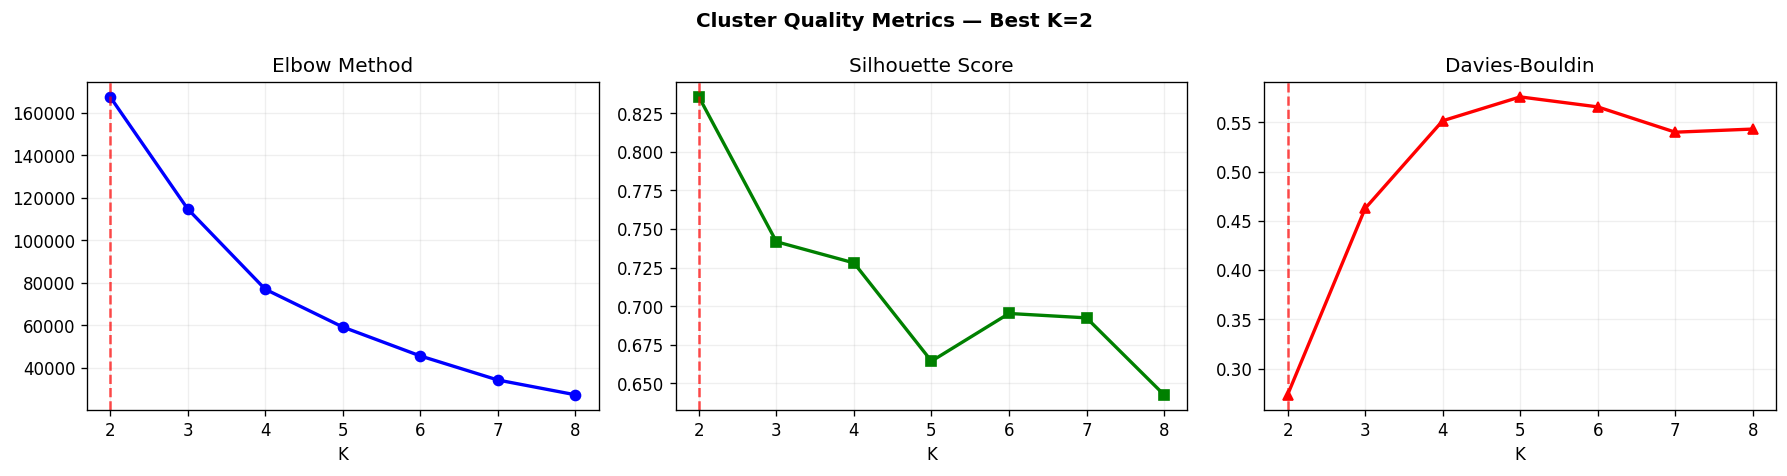

In [76]:
inertias, sil_scores, db_scores = [], [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))
    db_scores.append(davies_bouldin_score(X_pca, labels))

best_k = list(K_range)[np.argmax(sil_scores)]
print(f'Best K = {best_k}')
print(f'Silhouette Score : {max(sil_scores):.4f}  (>0.5 = good separation)')
print(f'Davies-Bouldin   : {db_scores[np.argmax(sil_scores)]:.4f}  (lower = better)')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(list(K_range), inertias, 'bo-', lw=2)
axes[0].axvline(best_k, color='red', linestyle='--', alpha=0.7)
axes[0].set_xlabel('K'); axes[0].set_title('Elbow Method'); axes[0].grid(True, alpha=0.2)

axes[1].plot(list(K_range), sil_scores, 'gs-', lw=2)
axes[1].axvline(best_k, color='red', linestyle='--', alpha=0.7)
axes[1].set_xlabel('K'); axes[1].set_title('Silhouette Score'); axes[1].grid(True, alpha=0.2)

axes[2].plot(list(K_range), db_scores, 'r^-', lw=2)
axes[2].axvline(best_k, color='red', linestyle='--', alpha=0.7)
axes[2].set_xlabel('K'); axes[2].set_title('Davies-Bouldin'); axes[2].grid(True, alpha=0.2)

plt.suptitle(f'Cluster Quality Metrics — Best K={best_k}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [77]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_pca)

results = X_imp.copy()
results['cluster']    = cluster_labels
results['pca1']       = X_2d[:, 0]
results['pca2']       = X_2d[:, 1]
results['sic']        = agg.loc[results.index, 'sic']

centroids = results.groupby('cluster')[X_imp.columns.tolist()].mean()

def name_cluster(row):
    if row['RevenueGrowth'] > 0.3 and row['ROE'] > 0.1:
        return 'High-Growth Tech'
    elif row['GrossMargin'] > 0.45 and row['DebtRatio'] < 0.5 and row['ROA'] > 0.05:
        return 'Profitable & Low-Debt'
    elif row['DebtRatio'] > 0.8:
        return 'Highly Leveraged'
    elif row['OperatingMargin'] < -0.05 and row['NetProfitMargin'] < -0.05:
        return 'Distressed / Loss-Making'
    elif row['CurrentRatio'] > 2 and row['GrossMargin'] > 0.3:
        return 'Stable & Well-Capitalized'
    elif row['GrossMargin'] > 0.3 and row['ROA'] > 0:
        return 'Stable Dividend / Mature'
    else:
        return 'Moderate / Mixed'

cluster_names = {i: name_cluster(centroids.loc[i]) for i in centroids.index}
results['cluster_name'] = results['cluster'].map(cluster_names)

print('Cluster Profiles:')
for c, name in cluster_names.items():
    n = (results['cluster'] == c).sum()
    print(f'  C{c}: {name:<30} — {n} companies')

key = ['GrossMargin','OperatingMargin','ROE','ROA','CurrentRatio','DebtRatio','RevenueGrowth']
print('\nCluster Centroids:')
centroids[key].round(3)


Cluster Profiles:
  C0: Stable & Well-Capitalized      — 848 companies
  C1: Highly Leveraged               — 132 companies

Cluster Centroids:


,GrossMargin,OperatingMargin,ROE,ROA,CurrentRatio,DebtRatio,RevenueGrowth
cluster,,,,,,,
0,0.364,-0.003,0.061,-0.066,2.487,0.669,0.953
1,0.322,-1.819,0.068,-0.459,2.525,1.169,1.060


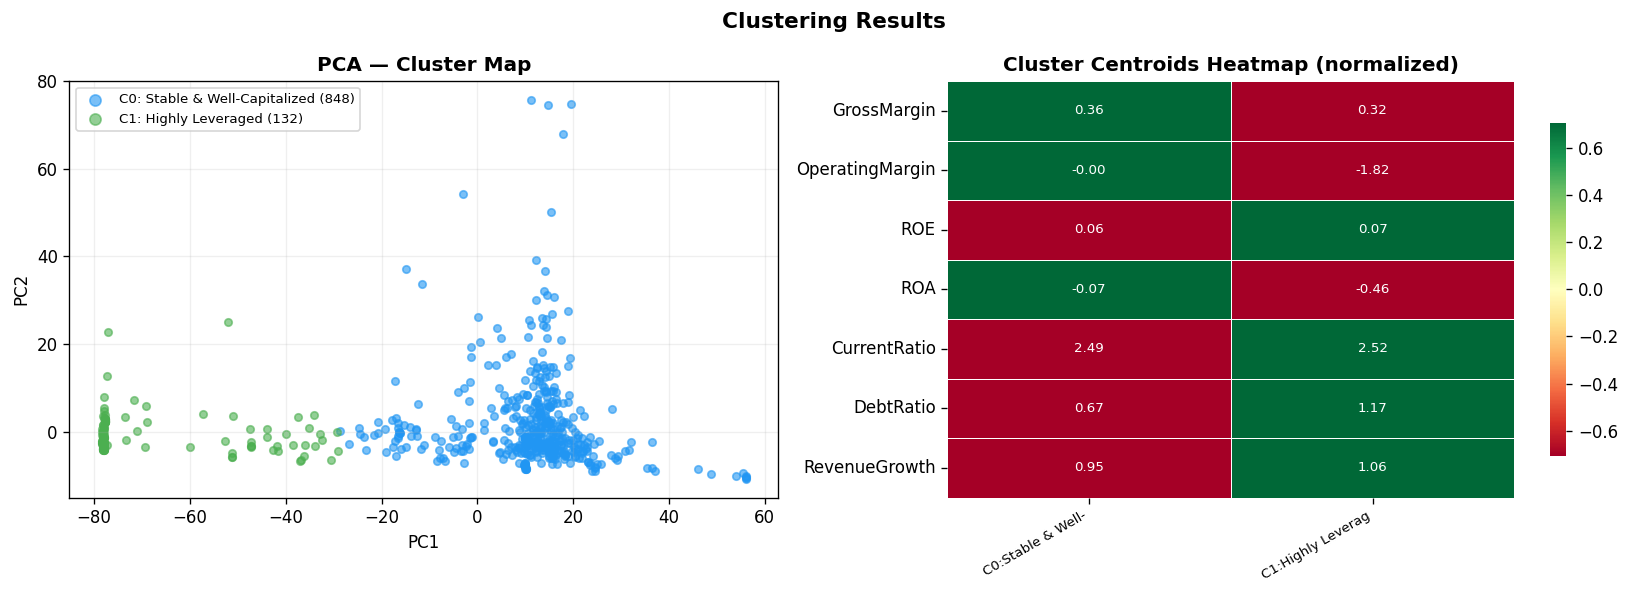

In [78]:
PALETTE = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4']
cmap_c = {i: PALETTE[i % len(PALETTE)] for i in range(best_k)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for c in range(best_k):
    m = results['cluster'] == c
    axes[0].scatter(results.loc[m,'pca1'], results.loc[m,'pca2'],
                    c=cmap_c[c], alpha=0.6, s=20,
                    label=f'C{c}: {cluster_names[c]} ({m.sum()})')
axes[0].set_title('PCA — Cluster Map', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=8, markerscale=1.5)
axes[0].grid(True, alpha=0.2)

heat = centroids[key].T
heat.columns = [f'C{c}:{cluster_names[c][:14]}' for c in heat.columns]
heat_n = heat.apply(lambda r: (r - r.mean()) / (r.std() + 1e-9), axis=1)
sns.heatmap(heat_n, ax=axes[1], cmap='RdYlGn', center=0,
            annot=heat.round(2), fmt='.2f', annot_kws={'size': 8},
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[1].set_title('Cluster Centroids Heatmap (normalized)', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.suptitle('Clustering Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Anomaly Detection — Isolation Forest

**Isolation Forest** phát hiện outliers bằng cách chia ngẫu nhiên feature space.
Điểm số thấp (âm) = dễ bị cô lập = bất thường.

**Các pattern anomaly thường gặp trong dữ liệu tài chính:**
- `DebtRatio >> 1` — Vốn chủ sở hữu âm (company in distress)
- `CurrentRatio = 10 (capped)` — Cash-rich biotech pre-revenue
- `ROE ở biên ±3` — Turnaround hoặc sụp đổ đột ngột
- `RevenueGrowth >> 5` — Acquisition spree hoặc data artifact
- `GrossMargin ≈ 100%` — Mô hình SaaS thuần / royalty


In [79]:
iso = IsolationForest(n_estimators=300, contamination=0.05, random_state=42)
iso.fit(X_scaled)

anomaly_preds  = iso.predict(X_scaled)
anomaly_scores = iso.decision_function(X_scaled)
is_anomaly = anomaly_preds == -1

results['is_anomaly']    = is_anomaly
results['anomaly_score'] = anomaly_scores

print(f'Anomalies: {is_anomaly.sum()} / {len(results)} ({is_anomaly.mean()*100:.1f}%)')

top_anom = results[results['is_anomaly']].sort_values('anomaly_score')
cols = ['anomaly_score','GrossMargin','ROE','DebtRatio','CurrentRatio','RevenueGrowth','cluster_name']
top_anom[cols].head(20).round(3)


Anomalies: 49 / 980 (5.0%)


,anomaly_score,GrossMargin,ROE,DebtRatio,CurrentRatio,RevenueGrowth,cluster_name
ticker,,,,,,,
ewlu,-0.075,0.670,0.060,5.000,0.017,-0.834,Highly Leveraged
sgmd,-0.074,0.341,0.432,5.000,0.160,10.000,Stable & Well-Capitalized
omex,-0.073,0.105,0.924,5.000,0.121,-0.266,Highly Leveraged
pzoo,-0.070,0.997,1.321,2.284,0.055,0.456,Stable & Well-Capitalized
zrfy,-0.068,0.967,0.175,5.000,0.022,5.276,Highly Leveraged
awh,-0.056,-0.012,-1.409,0.531,2.385,5.336,Highly Leveraged
acad,-0.055,-0.082,-0.337,0.086,10.000,10.000,Highly Leveraged
neik,-0.052,0.213,0.183,5.000,0.061,0.456,Stable & Well-Capitalized
ipsi,-0.051,0.030,-2.852,0.403,1.806,10.000,Highly Leveraged


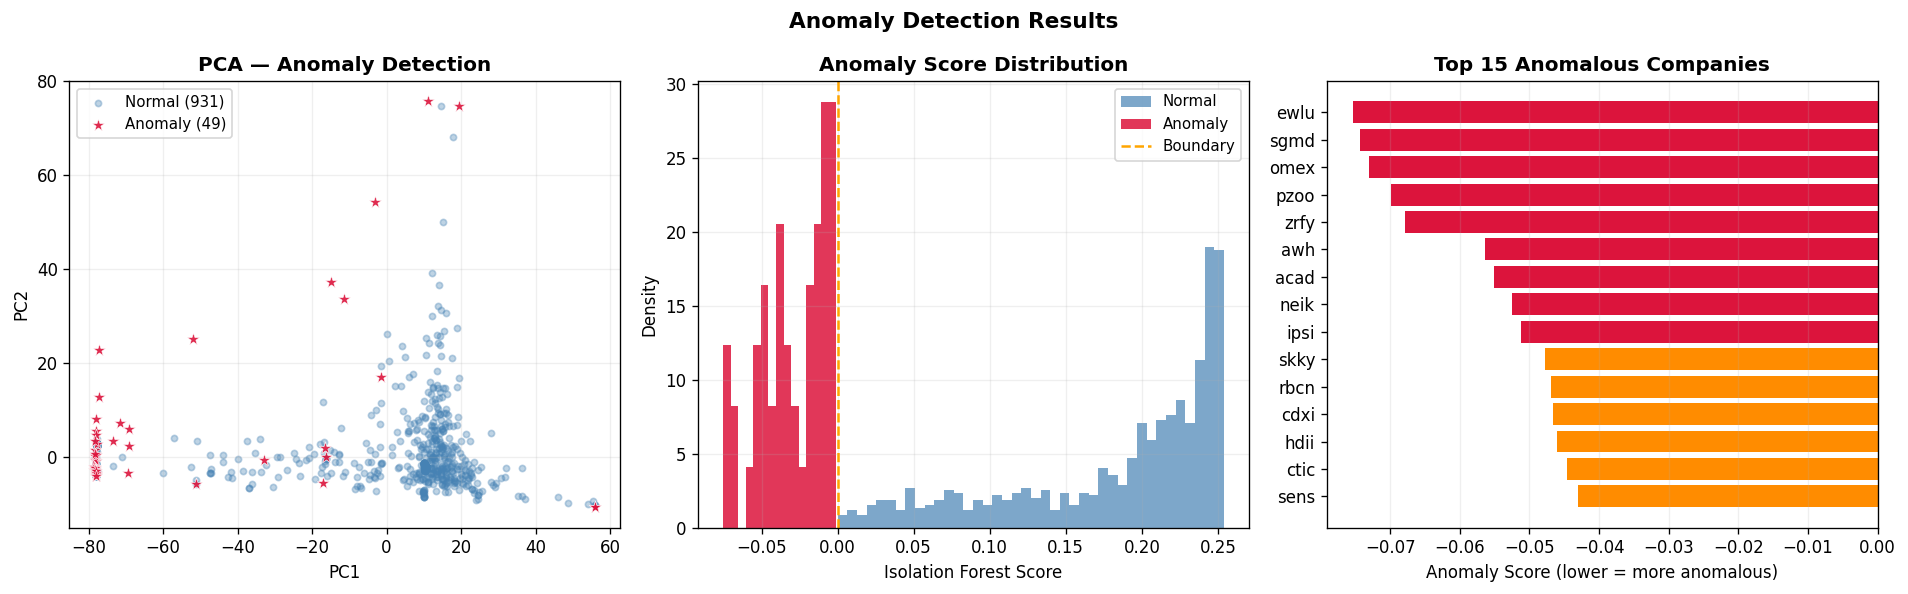

In [80]:
nm = ~results['is_anomaly']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# PCA + anomalies
axes[0].scatter(results.loc[nm,'pca1'], results.loc[nm,'pca2'],
                c='steelblue', alpha=0.35, s=14, label=f'Normal ({nm.sum()})')
axes[0].scatter(results.loc[is_anomaly,'pca1'], results.loc[is_anomaly,'pca2'],
                c='crimson', alpha=0.9, s=60, marker='*', zorder=5,
                label=f'Anomaly ({is_anomaly.sum()})',
                edgecolors='white', linewidths=0.4)
axes[0].set_title('PCA — Anomaly Detection', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.2)

# Score distribution
axes[1].hist(results.loc[nm,'anomaly_score'], bins=40,
             color='steelblue', alpha=0.7, density=True, label='Normal')
axes[1].hist(results.loc[is_anomaly,'anomaly_score'], bins=15,
             color='crimson', alpha=0.85, density=True, label='Anomaly')
axes[1].axvline(0, color='orange', linestyle='--', lw=1.5, label='Boundary')
axes[1].set_xlabel('Isolation Forest Score'); axes[1].set_ylabel('Density')
axes[1].set_title('Anomaly Score Distribution', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.2)

# Top anomaly bar
top15 = results[results['is_anomaly']].sort_values('anomaly_score').head(15)
bc = ['crimson' if s < -0.05 else 'darkorange' for s in top15['anomaly_score']]
axes[2].barh(top15.index[::-1], top15['anomaly_score'][::-1], color=bc[::-1])
axes[2].axvline(0, color='black', lw=0.5)
axes[2].set_xlabel('Anomaly Score (lower = more anomalous)')
axes[2].set_title('Top 15 Anomalous Companies', fontweight='bold')
axes[2].grid(True, alpha=0.2, axis='x')

plt.suptitle('Anomaly Detection Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Full Analysis Dashboard


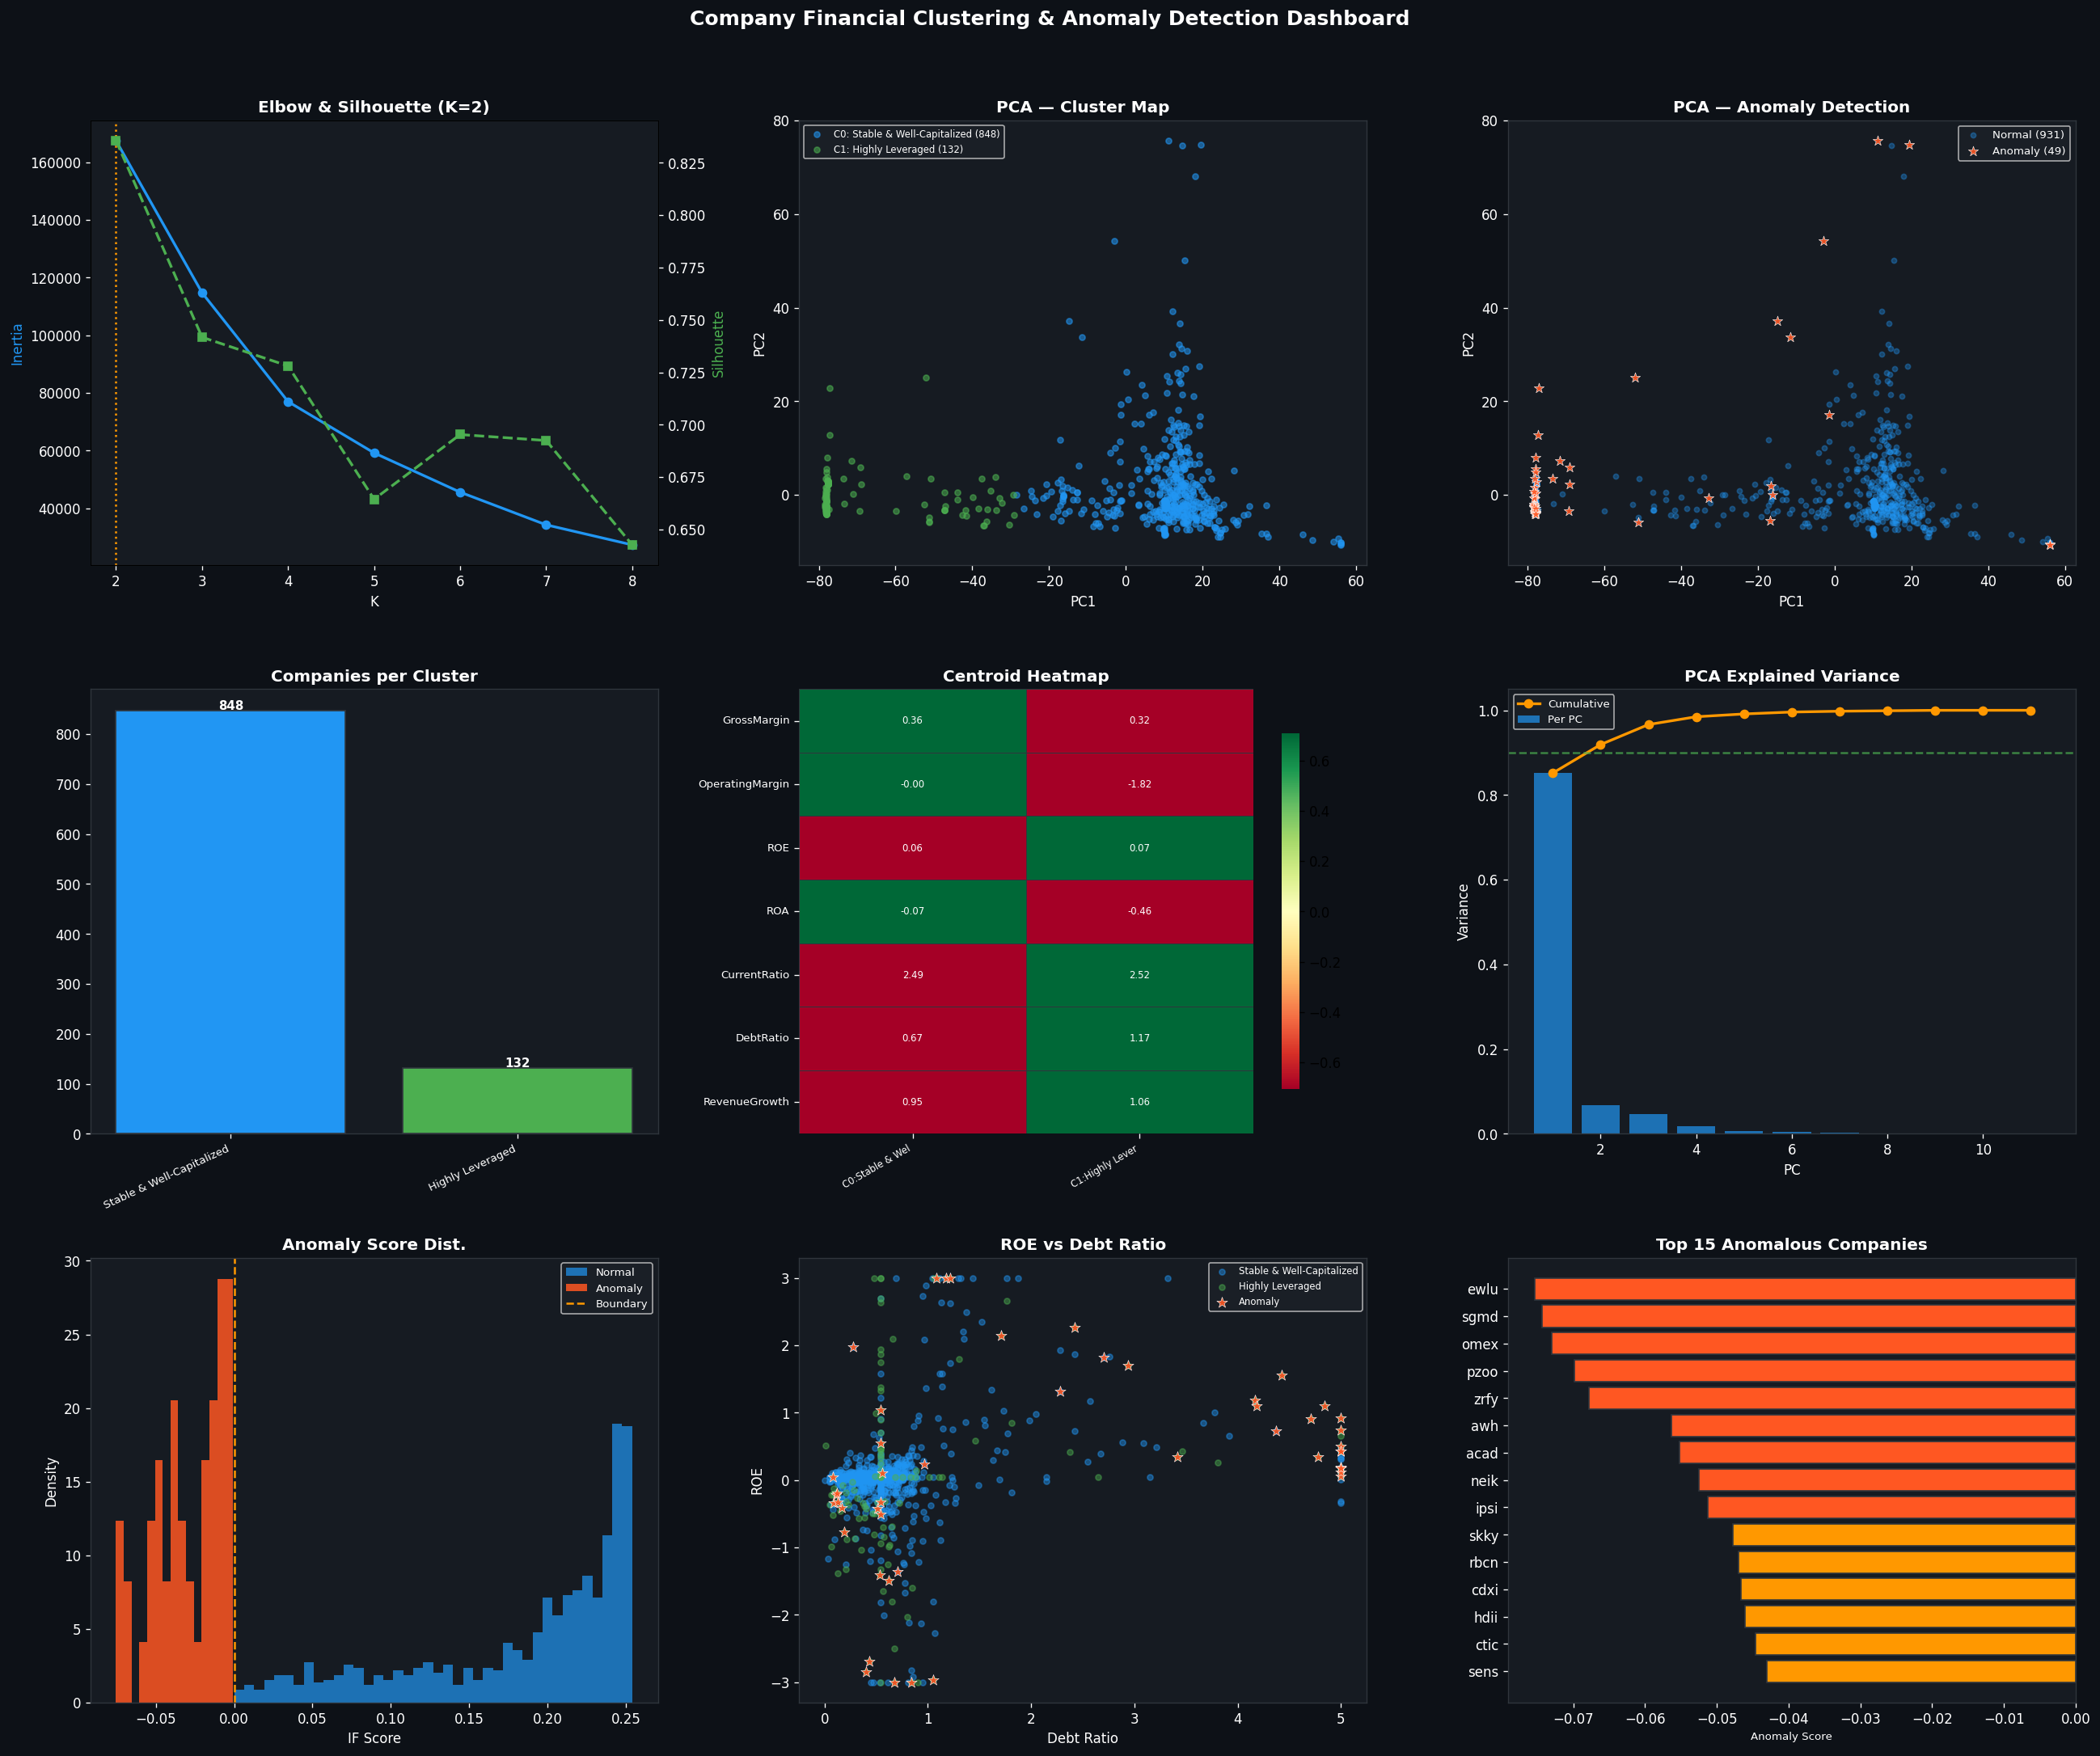

✓ Dashboard saved


In [81]:
PALETTE = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4']
cmap_c = {i: PALETTE[i % len(PALETTE)] for i in range(best_k)}
key = ['GrossMargin','OperatingMargin','ROE','ROA','CurrentRatio','DebtRatio','RevenueGrowth']

fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor('#0d1117')

def dark_ax(ax):
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='white')
    for s in ax.spines.values(): s.set_edgecolor('#30363d')
    return ax

# P1
ax1 = dark_ax(fig.add_subplot(3,3,1)); ax1b = ax1.twinx()
ax1.plot(list(K_range), inertias, 'o-', color='#2196F3', lw=2, label='Inertia')
ax1b.plot(list(K_range), sil_scores, 's--', color='#4CAF50', lw=2, label='Silhouette')
ax1.axvline(best_k, color='#FF9800', lw=1.5, linestyle=':')
ax1.set_title(f'Elbow & Silhouette (K={best_k})', color='white', fontweight='bold')
ax1.set_xlabel('K', color='white'); ax1.set_ylabel('Inertia', color='#2196F3')
ax1b.set_ylabel('Silhouette', color='#4CAF50'); ax1b.tick_params(colors='white')

# P2
ax2 = dark_ax(fig.add_subplot(3,3,2))
for c in range(best_k):
    m = results['cluster'] == c
    ax2.scatter(results.loc[m,'pca1'], results.loc[m,'pca2'],
                c=cmap_c[c], alpha=0.55, s=18, label=f'C{c}: {cluster_names[c]} ({m.sum()})')
ax2.set_title('PCA — Cluster Map', color='white', fontweight='bold')
ax2.set_xlabel('PC1',color='white'); ax2.set_ylabel('PC2',color='white')
ax2.legend(facecolor='#1c2128', labelcolor='white', fontsize=7)

# P3
ax3 = dark_ax(fig.add_subplot(3,3,3))
nm = ~results['is_anomaly']
ax3.scatter(results.loc[nm,'pca1'], results.loc[nm,'pca2'],
            c='#2196F3', alpha=0.35, s=14, label=f'Normal ({nm.sum()})')
ax3.scatter(results.loc[is_anomaly,'pca1'], results.loc[is_anomaly,'pca2'],
            c='#FF5722', alpha=0.9, s=60, marker='*', zorder=5,
            label=f'Anomaly ({is_anomaly.sum()})', edgecolors='white', linewidths=0.4)
ax3.set_title('PCA — Anomaly Detection', color='white', fontweight='bold')
ax3.set_xlabel('PC1',color='white'); ax3.set_ylabel('PC2',color='white')
ax3.legend(facecolor='#1c2128', labelcolor='white', fontsize=8)

# P4
ax4 = dark_ax(fig.add_subplot(3,3,4))
counts = results['cluster'].value_counts().sort_index()
names_ = [cluster_names[i] for i in counts.index]
bars = ax4.bar(names_, counts.values,
               color=[cmap_c[i] for i in counts.index], edgecolor='#30363d')
for bar, v in zip(bars, counts.values):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, str(v),
             ha='center', color='white', fontsize=9, fontweight='bold')
ax4.set_title('Companies per Cluster', color='white', fontweight='bold')
ax4.set_xticklabels(names_, rotation=25, ha='right', color='white', fontsize=8)

# P5
ax5 = dark_ax(fig.add_subplot(3,3,5))
heat = centroids[key].T
heat.columns = [f'C{c}:{cluster_names[c][:12]}' for c in heat.columns]
heat_n = heat.apply(lambda r: (r-r.mean())/(r.std()+1e-9), axis=1)
sns.heatmap(heat_n, ax=ax5, cmap='RdYlGn', center=0, linewidths=0.5,
            linecolor='#30363d', annot=heat.round(2), fmt='.2f',
            annot_kws={'size':7}, cbar_kws={'shrink':0.8})
ax5.set_title('Centroid Heatmap', color='white', fontweight='bold')
ax5.tick_params(colors='white', labelsize=7)
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=30, ha='right', color='white', fontsize=7)
ax5.set_yticklabels(ax5.get_yticklabels(), color='white', fontsize=8)

# P6
ax6 = dark_ax(fig.add_subplot(3,3,6))
evr = pca_full.explained_variance_ratio_[:12]
cv2 = np.cumsum(pca_full.explained_variance_ratio_)[:12]
ax6.bar(range(1,len(evr)+1), evr, color='#2196F3', alpha=0.7, label='Per PC')
ax6.plot(range(1,len(cv2)+1), cv2, 'o-', color='#FF9800', lw=2, label='Cumulative')
ax6.axhline(0.9, color='#4CAF50', linestyle='--', alpha=0.7)
ax6.set_xlabel('PC',color='white'); ax6.set_ylabel('Variance',color='white')
ax6.set_title('PCA Explained Variance', color='white', fontweight='bold')
ax6.legend(facecolor='#1c2128', labelcolor='white', fontsize=8)

# P7
ax7 = dark_ax(fig.add_subplot(3,3,7))
ax7.hist(results.loc[nm,'anomaly_score'], bins=40,
         color='#2196F3', alpha=0.7, density=True, label='Normal')
ax7.hist(results.loc[is_anomaly,'anomaly_score'], bins=15,
         color='#FF5722', alpha=0.85, density=True, label='Anomaly')
ax7.axvline(0, color='#FF9800', linestyle='--', lw=1.5, label='Boundary')
ax7.set_xlabel('IF Score',color='white'); ax7.set_ylabel('Density',color='white')
ax7.set_title('Anomaly Score Dist.', color='white', fontweight='bold')
ax7.legend(facecolor='#1c2128', labelcolor='white', fontsize=8)

# P8
ax8 = dark_ax(fig.add_subplot(3,3,8))
for c in range(best_k):
    m = results['cluster'] == c
    ax8.scatter(results.loc[m,'DebtRatio'], results.loc[m,'ROE'],
                c=cmap_c[c], alpha=0.45, s=18, label=cluster_names[c])
ax8.scatter(results.loc[is_anomaly,'DebtRatio'], results.loc[is_anomaly,'ROE'],
            c='#FF5722', s=70, marker='*', alpha=0.9, zorder=5,
            edgecolors='white', linewidths=0.4, label='Anomaly')
ax8.set_xlabel('Debt Ratio',color='white'); ax8.set_ylabel('ROE',color='white')
ax8.set_title('ROE vs Debt Ratio', color='white', fontweight='bold')
ax8.legend(facecolor='#1c2128', labelcolor='white', fontsize=7)

# P9
ax9 = dark_ax(fig.add_subplot(3,3,9))
top15 = results[results['is_anomaly']].sort_values('anomaly_score').head(15)
bc = ['#FF5722' if s < -0.05 else '#FF9800' for s in top15['anomaly_score']]
ax9.barh(top15.index[::-1], top15['anomaly_score'][::-1], color=bc[::-1], edgecolor='#30363d')
ax9.axvline(0, color='white', lw=0.5, alpha=0.4)
ax9.set_xlabel('Anomaly Score',color='white', fontsize=8)
ax9.set_title('Top 15 Anomalous Companies', color='white', fontweight='bold')

plt.suptitle('Company Financial Clustering & Anomaly Detection Dashboard',
             color='white', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(pad=2.0)
plt.savefig('clustering_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✓ Dashboard saved')


## 8. Summary & Export


In [82]:
print('='*65)
print('SUMMARY REPORT')
print('='*65)
print(f'Dataset    : {len(df):,} records | {df["ticker"].nunique()} companies | 2009-2021')
print(f'Analyzed   : {len(results)} companies (after feature cleaning)')
print(f'Features   : {len(X_imp.columns)} financial ratios')
print(f'PCA        : {n_components_90} components (90% variance)')
print(f'Clusters K : {best_k}')
print(f'Silhouette : {max(sil_scores):.4f}')
print(f'D-B Score  : {db_scores[np.argmax(sil_scores)]:.4f}')
print(f'Anomalies  : {is_anomaly.sum()} ({is_anomaly.mean()*100:.1f}%)')
print()
print('CLUSTER PROFILES:')
key2 = ['GrossMargin','OperatingMargin','ROE','DebtRatio','CurrentRatio','RevenueGrowth']
for c in range(best_k):
    n = (results['cluster'] == c).sum()
    r = centroids.loc[c]
    print(f'\n  [{c}] {cluster_names[c]}  ({n} companies)')
    print(f'      GrossMargin={r["GrossMargin"]:.1%}  OpMargin={r["OperatingMargin"]:.1%}')
    print(f'      ROE={r["ROE"]:.1%}  ROA={r["ROA"]:.1%}  DebtRatio={r["DebtRatio"]:.2f}')
    print(f'      CurrentRatio={r["CurrentRatio"]:.2f}  RevGrowth={r["RevenueGrowth"]:.1%}')

results.to_csv('company_clusters.csv')
print('\n✓ company_clusters.csv exported')


SUMMARY REPORT
Dataset    : 26,288 records | 1369 companies | 2009-2021
Analyzed   : 980 companies (after feature cleaning)
Features   : 11 financial ratios
PCA        : 2 components (90% variance)
Clusters K : 2
Silhouette : 0.8356
D-B Score  : 0.2733
Anomalies  : 49 (5.0%)

CLUSTER PROFILES:

  [0] Stable & Well-Capitalized  (848 companies)
      GrossMargin=36.4%  OpMargin=-0.3%
      ROE=6.1%  ROA=-6.6%  DebtRatio=0.67
      CurrentRatio=2.49  RevGrowth=95.3%

  [1] Highly Leveraged  (132 companies)
      GrossMargin=32.2%  OpMargin=-181.9%
      ROE=6.8%  ROA=-45.9%  DebtRatio=1.17
      CurrentRatio=2.52  RevGrowth=106.0%

✓ company_clusters.csv exported
